# 上下文扩展技巧：从提示到分层上下文

以实践为导向，演示如何将基础提示逐步演化为“分层、信息密度更高”的上下文结构，以提升大模型表现。重点在于：如何有策略地添加与组织上下文层，并系统化衡量它们对 token 开销与输出质量的影响。

- 由最小提示过渡到“信息丰富、结构清晰”的上下文
- 上下文分层与“组合式提示工程”的原则
- 随上下文增长对 token 使用与质量的测量与可视化
- 压缩与修剪：控制成本的关键技巧
- RAG：结合检索的上下文扩展

建议：逐格运行每个单元，改动提示与参数，观察对输出与指标的影响。


In [1]:
import os
import time
from typing import Dict, List, Tuple, Any, Optional

try:
    import matplotlib.pyplot as plt
    HAS_MPL = True
except Exception:
    plt = None
    HAS_MPL = False

# OpenAI 环境配置

USE_OPENAI = bool(os.getenv("OPENAI_API_KEY","TRUE"))
DEFAULT_MODEL = os.getenv("OPENAI_MODEL", "gpt-4o-mini")
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY","sk-R2utGqjya03Bgnc77273729e7b73457e97A140D79bF3B944") # Added API Key variable
OPENAI_BASE_URL = os.getenv("OPENAI_BASE_URL","https://api.apiyi.com/v1") # Added Base URL variable

if USE_OPENAI:
    try:
        from openai import OpenAI
        client: Optional[OpenAI] = OpenAI(api_key=OPENAI_API_KEY, base_url=OPENAI_BASE_URL) # Added api_key and base_url
        from tiktoken import encoding_for_model
        ENC = encoding_for_model(DEFAULT_MODEL)
    except Exception:
        client = None
        USE_OPENAI = False
else:
    client = None

# tiktoken 可选（用于精确计数），没装则退化为粗略估计
try:
    import tiktoken
    tokenizer = tiktoken.encoding_for_model(DEFAULT_MODEL) if USE_OPENAI else None
except Exception:
    tokenizer = None


def count_tokens(text: str) -> int:
    if tokenizer is not None:
        return len(tokenizer.encode(text))
    return int(len(text.split()) * 1.3)


def measure_latency(func, *args, **kwargs) -> Tuple[Any, float]:
    t0 = time.time()
    res = func(*args, **kwargs)
    t1 = time.time()
    return res, (t1 - t0)


In [2]:
def generate_response(prompt: str) -> Tuple[str, float]:
    if USE_OPENAI and client is not None:
        try:
            t0 = time.time()
            resp = client.chat.completions.create(
                model=DEFAULT_MODEL,
                messages=[{"role": "user", "content": prompt}],
                temperature=0.7,
                max_tokens=800,
            )
            latency = time.time() - t0
            return resp.choices[0].message.content or "", latency
        except Exception as e:
            return f"[OpenAI 调用失败：{e}]", 0.0
    # 无密钥：返回占位
    return f"[未检测到 OPENAI_API_KEY，占位响应]", 0.0


def calculate_metrics(prompt: str, response: str, latency: float) -> Dict[str, float]:
    pt = count_tokens(prompt)
    rt = count_tokens(response)
    eff = (rt / pt) if pt > 0 else 0.0
    latency_per_1k = (latency / pt) * 1000 if pt > 0 else 0.0
    return {
        "prompt_tokens": pt,
        "response_tokens": rt,
        "token_efficiency": eff,
        "latency": latency,
        "latency_per_1k": latency_per_1k,
    }


### 1. 从最小提示到扩展提示

定义基础提示与多种扩展变体（角色、示例、约束、受众、综合）。


In [3]:
base_prompt = "请写一段关于气候变化的说明文字。"

expanded_prompts = {
    "base": base_prompt,
    "with_role": "你是一名气候系统方向的环境科学家。\n请写一段关于气候变化的说明文字。",
    "with_examples": (
        "请写一段关于气候变化的说明文字。\n\n"
        "示例 1：\n气候变化指的是温度和天气模式的长期变化。自 19 世纪以来，人类活动一直是气候变化的主要驱动因素，尤其是燃烧煤、石油、天然气等化石燃料，会产生大量热量捕获性气体。\n\n"
        "示例 2：\n全球气候变化体现在极端天气事件的频率增加、海平面上升以及野生动物种群迁移。科学共识认为人类活动是主要原因。"
    ),
    "with_constraints": (
        "请写一段关于气候变化的说明文字。\n"
        "- 至少包含一个带数字的科学事实\n"
        "- 同时提及成因与影响\n"
        "- 以‘行动倡议’结尾\n"
        "- 保持信息性且通俗易懂的语气"
    ),
    "with_audience": (
        "请为刚开始接触环境科学的高中生，写一段关于气候变化的说明文字，\n"
        "尽量使用清晰解释与贴近生活的例子。"
    ),
    "comprehensive": (
        "你是一名气候系统方向的环境科学家。\n\n"
        "请为刚开始接触环境科学的高中生，写一段关于气候变化的说明文字，\n"
        "使用清晰解释与贴近生活的例子。\n\n"
        "写作指南：\n"
        "- 至少包含一个带数字的科学事实\n"
        "- 同时提及成因与影响\n"
        "- 以‘行动倡议’结尾\n"
        "- 保持信息性且通俗易懂的语气\n\n"
        "语气与结构示例：\n"
        "海洋酸化发生在海水从大气中吸收 CO2 时，导致 pH 值下降。自工业革命以来，海洋 pH 下降了约 0.1 个单位，酸度增加约 30%。这会影响海洋生物，尤其是贝类与珊瑚。"
    ),
}


In [4]:
results = {}
responses = {}
for name, p in expanded_prompts.items():
    print(f"测试：{name}")
    resp, lat = generate_response(p)
    responses[name] = resp
    results[name] = calculate_metrics(p, resp, lat)
    print("  提示 token：", results[name]["prompt_tokens"])
    print("  响应 token：", results[name]["response_tokens"])
    print("  时延：{:.2f}s".format(results[name]["latency"]))
    print("-" * 40)


测试：base
  提示 token： 12
  响应 token： 277
  时延：5.27s
----------------------------------------
测试：with_role
  提示 token： 24
  响应 token： 308
  时延：3.60s
----------------------------------------
测试：with_examples
  提示 token： 123
  响应 token： 184
  时延：2.85s
----------------------------------------
测试：with_constraints
  提示 token： 57
  响应 token： 239
  时延：3.39s
----------------------------------------
测试：with_audience
  提示 token： 37
  响应 token： 303
  时延：2.54s
----------------------------------------
测试：comprehensive
  提示 token： 174
  响应 token： 333
  时延：4.49s
----------------------------------------


/tmp/ipython-input-2321003248.py:32: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2321003248.py:32: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2321003248.py:32: UserWarning: Glyph 20351 (\N{CJK UNIFIED IDEOGRAPH-4F7F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2321003248.py:32: UserWarning: Glyph 29992 (\N{CJK UNIFIED IDEOGRAPH-7528}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2321003248.py:32: UserWarning: Glyph 25552 (\N{CJK UNIFIED IDEOGRAPH-63D0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2321003248.py:32: UserWarning: Glyph 31034 (\N{CJK UNIFIED IDEOGRAPH-793A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2321003248.py:32: UserWarning: Glyph 21709 (\N{CJK UNIFIED IDEOGRAPH-54CD}) missi

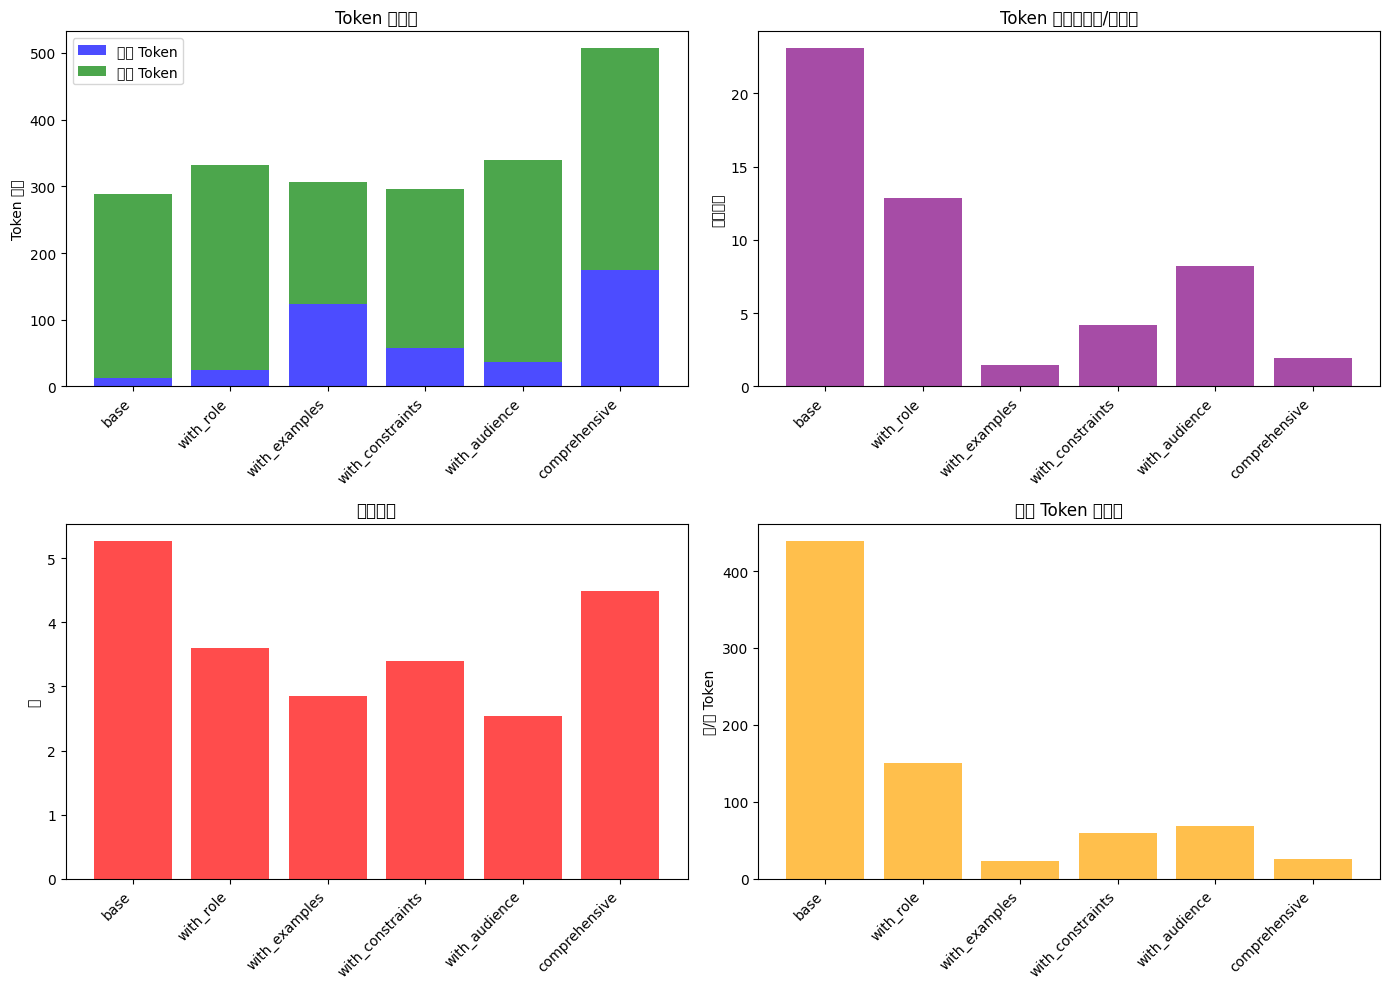

In [5]:
prompt_types = list(results.keys())
prompt_tokens = [results[k]['prompt_tokens'] for k in prompt_types]
response_tokens = [results[k]['response_tokens'] for k in prompt_types]
latencies = [results[k]['latency'] for k in prompt_types]

def plot_bars():
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes[0, 0].bar(prompt_types, prompt_tokens, label='提示 Token', alpha=0.7, color='blue')
    axes[0, 0].bar(prompt_types, response_tokens, bottom=prompt_tokens, label='响应 Token', alpha=0.7, color='green')
    axes[0, 0].set_title('Token 使用量')
    axes[0, 0].set_ylabel('Token 数量')
    axes[0, 0].legend()
    plt.setp(axes[0, 0].get_xticklabels(), rotation=45, ha='right')

    token_efficiency = [results[k]['token_efficiency'] for k in prompt_types]
    axes[0, 1].bar(prompt_types, token_efficiency, color='purple', alpha=0.7)
    axes[0, 1].set_title('Token 效率（响应/提示）')
    axes[0, 1].set_ylabel('效率比值')
    plt.setp(axes[0, 1].get_xticklabels(), rotation=45, ha='right')

    axes[1, 0].bar(prompt_types, latencies, color='red', alpha=0.7)
    axes[1, 0].set_title('响应时延')
    axes[1, 0].set_ylabel('秒')
    plt.setp(axes[1, 0].get_xticklabels(), rotation=45, ha='right')

    latency_per_1k = [results[k]['latency_per_1k'] for k in prompt_types]
    axes[1, 1].bar(prompt_types, latency_per_1k, color='orange', alpha=0.7)
    axes[1, 1].set_title('每千 Token 的时延')
    axes[1, 1].set_ylabel('秒/千 Token')
    plt.setp(axes[1, 1].get_xticklabels(), rotation=45, ha='right')

    plt.tight_layout()

if HAS_MPL:
    plot_bars(); plt.show()
else:
    print('[未安装 matplotlib，跳过可视化]')


### 3. 模板化：扩展上下文生成器


In [7]:
from typing import Optional

def create_expanded_context(
    base_prompt: str,
    role: Optional[str] = None,
    examples: Optional[List[str]] = None,
    constraints: Optional[List[str]] = None,
    audience: Optional[str] = None,
    tone: Optional[str] = None,
    output_format: Optional[str] = None,
) -> str:
    parts: List[str] = []
    if role:
        parts.append(f"你的身份：{role}。")
    parts.append(base_prompt)
    if audience:
        parts.append(f"请确保你的回答适合：{audience}。")
    if tone:
        parts.append(f"请使用 {tone} 的语气进行回答。")
    if output_format:
        parts.append(f"请将输出格式化为：{output_format}。")
    if constraints:
        parts.append("要求：")
        parts.extend([f"- {c}" for c in constraints])
    if examples:
        parts.append("示例：")
        parts.extend([f"示例 {i+1}：\n{ex}" for i, ex in enumerate(examples)])
    return "\n\n".join(parts)


In [8]:
new_base_prompt = "请解释光合作用的工作原理。"
new_expanded_context = create_expanded_context(
    base_prompt=new_base_prompt,
    role="一位有 15 年教学经验的生物老师",
    audience="初中学生",
    tone="热情且富有教育性",
    constraints=[
        "使用‘植物工厂’类比来说明",
        "提及叶绿素的作用",
        "解释其对地球生态的重要性",
        "全文不超过 200 字",
    ],
    examples=[
        "光合作用就像植物体内的一家‘小工厂’……（示例内容略）",
    ],
)

print("模板生成的扩展上下文：\n", new_expanded_context)
resp, lat = generate_response(new_expanded_context)
metrics = calculate_metrics(new_expanded_context, resp, lat)
print("\n响应：\n", resp)
print("响应 token：", metrics["response_tokens"])


模板生成的扩展上下文：
 你的身份：一位有 15 年教学经验的生物老师。

请解释光合作用的工作原理。

请确保你的回答适合：初中学生。

请使用 热情且富有教育性 的语气进行回答。

要求：

- 使用‘植物工厂’类比来说明

- 提及叶绿素的作用

- 解释其对地球生态的重要性

- 全文不超过 200 字

示例：

示例 1：
光合作用就像植物体内的一家‘小工厂’……（示例内容略）

响应：
 光合作用就像植物体内的一家“小工厂”，在这里，植物利用阳光、二氧化碳和水，制造出自己的食物和氧气。首先，植物的叶子中含有一种叫叶绿素的绿色物质，就像小工厂的“工人”，它可以捕捉阳光的能量。然后，植物将阳光的能量与空气中的二氧化碳和根部吸收的水结合，经过一系列化学反应，最终生产出葡萄糖（植物的食物）和氧气。

光合作用不仅让植物生存，还为地球提供了氧气，使我们可以呼吸。更重要的是，植物通过这个过程吸收了二氧化碳，帮助减少温室气体的影响，维持生态平衡。可以说，光合作用是地球上生命的源泉，保护好这些“小工厂”，就是保护我们的家园！
响应 token： 210


### 4. 上下层优化（Layer Optimization）

对不同上下文层的组合进行系统测试，比较指标与最优配置。


In [9]:
def test_layered_contexts(base_prompt: str, context_layers: Dict[str, str]) -> Dict[str, Dict[str, Any]]:
    layer_results: Dict[str, Dict[str, Any]] = {}
    print("测试：base")
    base_resp, base_lat = generate_response(base_prompt)
    layer_results["base"] = {
        "prompt": base_prompt,
        "response": base_resp,
        **calculate_metrics(base_prompt, base_resp, base_lat),
    }
    for layer_name, layer_content in context_layers.items():
        name = f"base+{layer_name}"
        prompt = f"{base_prompt}\n\n{layer_content}"
        print(f"测试：{name}")
        resp, lat = generate_response(prompt)
        layer_results[name] = {
            "prompt": prompt,
            "response": resp,
            **calculate_metrics(prompt, resp, lat),
        }
    all_layers = "\n\n".join(context_layers.values())
    full_prompt = f"{base_prompt}\n\n{all_layers}"
    print("测试：all_layers")
    full_resp, full_lat = generate_response(full_prompt)
    layer_results["all_layers"] = {
        "prompt": full_prompt,
        "response": full_resp,
        **calculate_metrics(full_prompt, full_resp, full_lat),
    }
    return layer_results

layer_test_prompt = "请实现一个简单的天气应用。"
context_layers = {
    "role": "你的身份：一名资深全栈工程师，兼具 UI/UX 设计经验。",
    "requirements": "需求：\n- 展示当前温度与未来 3 天预报\n- 城市名称搜索\n- 自适应界面\n- 友好错误处理",
    "tech_stack": "技术规格：\n- HTML / CSS / 原生 JavaScript\n- OpenWeatherMap API\n- 注释清晰、符合最佳实践",
}
layer_test_results = test_layered_contexts(layer_test_prompt, context_layers)

best = max(layer_test_results.keys(), key=lambda k: layer_test_results[k]['token_efficiency'])
print("Token 效率最高配置：", best)


测试：base
测试：base+role
测试：base+requirements
测试：base+tech_stack
测试：all_layers
Token 效率最高配置： base


### 5. 上下文压缩（摘要/关键词/要点）

将长上下文压缩为更短但保留关键信息的版本。


In [10]:
def compress_context(context: str, technique: str = 'summarize') -> str:
    if technique == 'summarize':
        prompt = f"请精炼以下上下文，保留关键信息并减少冗余：\n\n{context}"
    elif technique == 'keywords':
        prompt = f"请提取以下上下文的关键词与关键短语（逗号分隔）：\n\n{context}"
    elif technique == 'bullet':
        prompt = f"请将以下上下文转换为结构化要点列表，覆盖核心信息：\n\n{context}"
    else:
        return context
    resp, _ = generate_response(prompt)
    return resp

original_context = expanded_prompts["comprehensive"]
print("原始 token：", count_tokens(original_context))
for tech in ['summarize', 'keywords', 'bullet']:
    out = compress_context(original_context, tech)
    print(f"\n{tech.upper()}\n", out)
    print("压缩后 token：", count_tokens(out))


原始 token： 174

SUMMARIZE
 气候变化是指全球气温上升和气候模式改变的现象。自1880年以来，全球平均气温已上升约1.2摄氏度。这主要是由于人类活动，如燃烧化石燃料和砍伐森林，释放大量二氧化碳（CO2）和其他温室气体。气候变化导致极端天气事件增多，例如更频繁的热浪、干旱和暴雨，直接影响我们的生活和生态环境。

例如，随着气温升高，冰川融化速度加快，导致海平面上升，威胁沿海城市和生态系统。为了应对气候变化，我们每个人都可以采取行动：减少能源消耗，选择公共交通或骑行、支持可再生能源，参与植树活动。让我们共同努力，保护我们的地球！
压缩后 token： 190

KEYWORDS
 气候变化, 环境科学, 高中生, 清晰解释, 生活例子, 科学事实, 成因, 影响, 行动倡议, 信息性, 通俗易懂, 海洋酸化, CO2, pH 值, 工业革命, 海洋生物, 贝类, 珊瑚
压缩后 token： 73

BULLET
 ### 气候变化说明要点

- **定义**：气候变化是指地球气候系统长期变化的现象，主要由人为活动导致。

- **科学事实**：自1880年以来，地球的平均气温上升了约1.2摄氏度，这一变化对气候模式产生了显著影响。

- **成因**：
  - **温室气体排放**：燃烧化石燃料（如煤、石油和天然气）释放二氧化碳（CO2）。
  - **森林砍伐**：减少了吸收CO2的树木数量，导致更多的温室气体留在大气中。

- **影响**：
  - **极端天气**：气候变化导致更多的热浪、暴雨和干旱现象。
  - **海平面上升**：由于冰川融化，海平面上升可能导致沿海地区的洪水风险增加。
  - **生态系统变化**：许多动植物的栖息环境受到威胁，可能导致物种灭绝。

- **生活中的例子**：例如，许多地方的农作物因异常天气受到影响，导致粮食价格上涨，影响我们的日常生活。

- **行动倡议**：我们每个人都可以通过减少能源消耗、使用公共交通、支持可再生能源等方式来应对气候变化，保护我们的地球。
压缩后 token： 321


### 6. 上下文修剪：系统化删除无效层（可选）

使用模型自评来比较不同层组合下的质量分，并递归删除无效层。


In [11]:
import re

def evaluate_response_quality(prompt: str, response: str, criteria: List[str]) -> float:
    crit = "\n".join([f"- {c}" for c in criteria])
    eval_prompt = (
        "请为以下响应基于标准打分，最后给出‘总体评分：0.0-1.0’。\n\n"
        f"提示：\n{prompt}\n\n响应：\n{response}\n\n评估标准：\n{crit}\n"
    )
    eval_resp, _ = generate_response(eval_prompt)
    m = re.findall(r"总体评分[:：]\s*([0-9]*\.?[0-9]+)", eval_resp)
    return float(m[-1]) if m else 0.5


def prune_context_layers(base_prompt: str, layers: Dict[str, str], criteria: List[str]) -> Tuple[str, Dict[str, Any]]:
    print("测试：base")
    base_resp, base_lat = generate_response(base_prompt)
    base_quality = evaluate_response_quality(base_prompt, base_resp, criteria)
    results: Dict[str, Any] = {
        "base": {"prompt": base_prompt, "quality": base_quality, "tokens": count_tokens(base_prompt)}
    }
    all_text = "\n\n".join(layers.values())
    full_prompt = f"{base_prompt}\n\n{all_text}"
    print("测试：all_layers")
    full_resp, _ = generate_response(full_prompt)
    full_quality = evaluate_response_quality(full_prompt, full_resp, criteria)
    results["all_layers"] = {"prompt": full_prompt, "quality": full_quality, "tokens": count_tokens(full_prompt)}

    best_quality = full_quality
    best_key = "all_layers"
    for name in list(layers.keys()):
        remain = {k: v for k, v in layers.items() if k != name}
        test_prompt = f"{base_prompt}\n\n" + "\n\n".join(remain.values())
        print(f"测试：without_{name}")
        test_resp, _ = generate_response(test_prompt)
        q = evaluate_response_quality(test_prompt, test_resp, criteria)
        key = f"without_{name}"
        results[key] = {"prompt": test_prompt, "quality": q, "tokens": count_tokens(test_prompt)}
        if q >= best_quality:
            best_quality, best_key = q, key

    if best_key == "all_layers":
        return full_prompt, results
    if best_key.startswith("without_"):
        removed = best_key.replace("without_", "")
        new_layers = {k: v for k, v in layers.items() if k != removed}
        return prune_context_layers(base_prompt, new_layers, criteria)
    return results[best_key]["prompt"], results


### 7. 结合检索（RAG）

用简单关键词匹配演示从“知识库”取回信息并拼接到提示中。


In [12]:
from typing import Dict as TDict

def retrieve_relevant_info(query: str, knowledge_base: List[TDict[str, str]]) -> List[str]:
    q_terms = set(query.lower().split())
    hits: List[Tuple[int, str]] = []
    for item in knowledge_base:
        content = item['content'].lower()
        title = item['title'].lower()
        score = sum(1 for t in q_terms if t in content or t in title)
        if score > 0:
            hits.append((score, item['content']))
    hits.sort(key=lambda x: x[0], reverse=True)
    return [h[1] for h in hits[:3]]

kb = [
    {"title": "Pandas Introduction", "content": "Pandas is a fast, powerful..."},
    {"title": "Loading Data in Pandas", "content": "Pandas can read data from CSV/Excel/SQL..."},
    {"title": "Data Cleaning", "content": "Use dropna() and fillna() to handle missing data."},
]

def create_rag_context(base_prompt: str, query: str, kb_list: List[TDict[str, str]]) -> str:
    infos = retrieve_relevant_info(query, kb_list)
    if not infos:
        return base_prompt
    return base_prompt + "\n\n相关信息：\n\n" + "\n\n".join(infos)

rag_prompt = "请简要讲解如何在 pandas 中读取数据并处理缺失值。"
rag_ctx = create_rag_context(rag_prompt, "pandas loading data cleaning", kb)
print(rag_ctx)
rag_resp, _ = generate_response(rag_ctx)
print("\nRAG 响应：\n", rag_resp)


请简要讲解如何在 pandas 中读取数据并处理缺失值。

相关信息：

Pandas can read data from CSV/Excel/SQL...

Use dropna() and fillna() to handle missing data.

Pandas is a fast, powerful...

RAG 响应：
 在 Pandas 中，读取数据和处理缺失值是数据分析中的常见任务。以下是一个简要的指南：

### 1. 读取数据

Pandas 可以从多种格式读取数据，包括 CSV、Excel、SQL 等。以下是一些常用的读取方法：

- **读取 CSV 文件**：
  ```python
  import pandas as pd
  
  df = pd.read_csv('data.csv')
  ```

- **读取 Excel 文件**：
  ```python
  df = pd.read_excel('data.xlsx', sheet_name='Sheet1')
  ```

- **从 SQL 数据库读取**：
  ```python
  import sqlite3
  
  conn = sqlite3.connect('database.db')
  df = pd.read_sql_query('SELECT * FROM table_name', conn)
  ```

### 2. 处理缺失值

在数据分析中，处理缺失值是非常重要的一步。Pandas 提供了 `dropna()` 和 `fillna()` 方法来处理缺失数据。

- **删除缺失值**：
  使用 `dropna()` 方法可以删除包含缺失值的行或列。
  ```python
  # 删除包含缺失值的行
  df_cleaned = df.dropna()
  
  # 删除包含缺失值的列
  df_cleaned = df.dropna(axis=1)
  ```

- **填充缺失值**：
  使用 `fillna()` 方法可以用特定值或其他计算结果填充缺失值。
  ```python
  # 用 0 填充缺失值
  df_filled = df.fillna(0)
  
  # 用列的均值填充缺失值
  df_filled = 

### 8. 结论与下一步

- 从最小提示开始，逐层扩展并量化影响
- 使用压缩与修剪降低 token 成本
- 在需要时结合检索构建高效上下文
- 模板化组织可复用提示结构

下一步：尝试在你的任务上复用此模板，并将“质量/一致性”替换为更贴合业务的评价指标。
